# Phase 1 main experiment (part 1g): does *decorrelation* restore explanation localization?

**Where this comes from.** 07f swept the relevant set's correlation and returned
`H2-REFUTED-FLAT`, but on inspection the verdict over-claimed: the "weak-correlation"
level it treated as decisive had **external leakage 0.368**, not zero. The CICIDS feature
space is so collinear (median per-feature max|corr| = 0.95) that a 10-feature relevant set
with leakage below ~0.37 is **unconstructable** — the proxy-exclusion only removed one
partner per feature, and there are many others. So 07f never reached the regime where the
identifiability mechanism predicts recovery. It showed localization is flat-near-chance
across leakage 0.37 -> 1.00; it did **not** show "SHAP fails even when decorrelated."

**What 07g does.** Three parts that close that hole.

1. **Redundancy distribution** — count how many of the 82 features have low redundancy.
   This is the precise structural-impossibility statement: to build a decorrelated
   relevant set of size *k* you need *k* features below the leakage threshold; if fewer
   than *k* exist, real CICIDS cannot reach the regime at all.

2. **Real-data decorrelated-limit arm** — select the **lowest-redundancy** features (not
   the 10th-percentile-targeted ones), with a small relevant set, to push external leakage
   as low as the real geometry permits. Report the *achieved* minimum leakage as a
   construction check, then measure whether SHAP recovers there. A high-redundancy real
   set is carried as contrast.

3. **Synthetic control arm (decisive).** The only place leakage can actually reach ~0.
   Build a pool with a genuinely independent relevant set plus controllable proxies at
   correlation rho, sweep rho from 0 upward, and ask the mechanism question directly:
   *with no proxies (rho=0), does SHAP recover the true relevant set, and does adding
   proxies degrade it?* This is the test 07f could not run.

**The mechanism under test (H2b / identifiability).** SHAP attributing to a proxy is
*faithful* — the model used the proxy, so a faithful explainer points there. The
localization "failure" is then a **non-identifiability** problem: when proxies exist, no
model-faithful importance method can isolate the true relevant set from its
interchangeable substitutes. Prediction: remove the proxies (leakage -> 0) and *every*
faithful method, SHAP included, must recover the set, because the model is forced to use
it.

**Three honest outcomes (pre-registered in D023).**
- *Identifiability confirmed + IDS structurally blocked* — synthetic SHAP recovers at
  rho=0 and degrades with rho, **and** real CICIDS cannot reach low leakage. This is the
  complete causal story: explanations fail on IDS data for a precise, measurable reason
  (structural redundancy), with a deployment diagnostic (the redundancy distribution).
- *Identifiability confirmed + real positive pole* — synthetic confirms the mechanism
  **and** real CICIDS reaches low leakage where SHAP also recovers. A real-data positive
  pole survives.
- *Identifiability refuted* — synthetic SHAP fails to recover even at rho=0, with a
  perfectly identifiable target. Then correlation is not the story, explanation
  localization is simply unreliable, and the unconditional negative hardens.

This **does not replace 07f** — it is a follow-on that supplies the regime 07f could not
construct. 07f's record (F010, its curve, D022) stands as the audit trail.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07g_decorrelated_limit.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)
print(f'{N_FEATURES} real features available.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'aux_shap': '#E69F00', 'ks': '#0072B2', 'random': '#000000'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07g_decorrelated_limit'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

82 real features available.
Setup complete.


## 2. D023 — the decorrelated-limit test, H2b, and the pre-registered gate

07f's `H2-REFUTED-FLAT` was construction-limited: its lowest leakage was 0.37, so the
decisive low-correlation regime was never reached. D023 fixes this by (a) quantifying how
low real CICIDS can go, and (b) building a synthetic arm where leakage genuinely reaches
zero, isolating the identifiability mechanism. The gate below is committed before
execution.

In [3]:
log_decision(
    decision_id='D023',
    decision=(
        'Test the identifiability mechanism behind localization failure, isolating it '
        'from real CICIDS geometry. (1) Report the feature-redundancy distribution to '
        'quantify how many features fall below given leakage thresholds (structural '
        'reachability). (2) Real-data arm: select the LOWEST-redundancy features (small '
        'relevant set) to push external leakage as low as the real geometry permits; '
        'measure aux-SHAP recovery there, with a high-redundancy set as contrast. '
        '(3) Synthetic control arm: build a pool with a genuinely independent relevant '
        'set plus proxies at controllable correlation rho, sweep rho from 0 upward, and '
        'measure aux-SHAP recovery of the known relevant set (KS carried as the '
        'concept-blind baseline). '
        'Pre-registered H2b (identifiability): with no proxies (rho=0) SHAP recovers the '
        'relevant set; adding proxies degrades it. Gate (committed before execution): '
        'MECHANISM-CONFIRMED iff synthetic aux-SHAP precision at rho=0 >= 0.50 AND '
        '(precision[rho=0] - precision[rho=max]) >= 0.20. MECHANISM-REFUTED iff synthetic '
        'aux-SHAP precision at rho=0 < 0.50 (fails even with a perfectly identifiable '
        'target). Real reachability: REACHED iff the lowest-redundancy real set achieves '
        'external leakage <= 0.20; if reached, real recovery holds iff its aux-SHAP '
        'precision >= 0.50. KS is expected at chance throughout (concept drift is '
        'invisible to input statistics).'
    ),
    rationale=(
        '07f could not construct a decorrelated relevant set on CICIDS (min leakage 0.37, '
        'median feature redundancy 0.95), so its flat-near-chance result cannot '
        'distinguish "correlation does not matter" from "could not escape correlation". '
        'The synthetic arm reaches leakage 0 and answers the mechanism question directly; '
        'the real arm answers whether CICIDS can ever reach that regime. Together they '
        'yield either a complete causal story (mechanism holds, IDS structurally blocks '
        'it) or a genuine unconditional refutation (mechanism fails with a clean target).'
    ),
    alternatives=(
        'Accept 07f H2-REFUTED-FLAT as-is (rejected: the low level was leakage 0.37, not '
        'decorrelated, so the conclusion over-claims and leaves a reviewer hole). '
        'Real-data sweep only (rejected: the decisive low-leakage regime is unreachable '
        'on CICIDS, so the mechanism cannot be tested without the synthetic control).'
    ),
)

[DECISION LOGGED] D023


## 3. Configuration

Small relevant set (`REL_SIZE = 5`) so the real arm can draw from the genuinely
low-redundancy tail, and `precision@5` against it. `RHO_LEVELS` are the synthetic
external-correlation knobs (achieved leakage ~= rho). Gate thresholds restate D023.

In [4]:
set_global_seed(42)

N_POOL = 40000
ARM_N = 8000
REL_SIZE = 5
GT_SIZE = REL_SIZE
K_PRIMARY = REL_SIZE
SHAP_SAMPLE = 1500
SEEDS = [42, 1, 7]
RHO_LEVELS = [0.0, 0.3, 0.6, 0.9, 0.99]    # synthetic external-correlation knob
RED_THRESHOLDS = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]   # for the redundancy distribution
METHODS = ['aux_shap', 'ks', 'random']
CHANCE = random_precision_expectation(GT_SIZE, N_FEATURES)

# Pre-registered gate thresholds (see D023):
SYN_LOW_MIN = 0.50       # synthetic SHAP must recover at rho=0 (clean identifiable target)
SYN_TREND_MIN = 0.20     # synthetic precision[rho=0] - precision[rho=max]
REAL_DECORR_MAX = 0.20   # real set counts as 'decorrelated' iff achieved leakage <= this
RECOVER_MIN = 0.50       # SHAP recovery bar (real arm, if it reaches the regime)

print(f'Chance precision@{K_PRIMARY} = {CHANCE:.3f}  |  GT_SIZE={GT_SIZE} of {N_FEATURES}')
print(f'Synthetic rho levels: {RHO_LEVELS}')
print(f'MECHANISM-CONFIRMED iff: SHAP_syn(rho=0) >= {SYN_LOW_MIN} & '
      f'trend(rho0 - rhoMax) >= {SYN_TREND_MIN}.')
print(f'Real REACHED iff: min achievable leakage <= {REAL_DECORR_MAX}; '
      f'real recovery iff SHAP >= {RECOVER_MIN} there.')

Chance precision@5 = 0.061  |  GT_SIZE=5 of 82
Synthetic rho levels: [0.0, 0.3, 0.6, 0.9, 0.99]
MECHANISM-CONFIRMED iff: SHAP_syn(rho=0) >= 0.5 & trend(rho0 - rhoMax) >= 0.2.
Real REACHED iff: min achievable leakage <= 0.2; real recovery iff SHAP >= 0.5 there.


## 4. Real feature pool, correlation structure, and the redundancy distribution

`REDUNDANCY[i]` is feature *i*'s strongest absolute correlation to any other feature. The
**count below each threshold** is the reachability statement: to build a relevant set of
size *k* with external leakage below *t*, at least *k* features must have redundancy below
*t*. 07f implied the 10th percentile is ~0.37; this makes the whole distribution explicit.

In [5]:
X_raw, _, _ = load_cicids2017(day='monday')
X_raw = X_raw.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
idx = np.random.default_rng(42).choice(len(X_raw), size=min(N_POOL, len(X_raw)), replace=False)
Xp = X_raw.iloc[idx].to_numpy(dtype=float)
mu, sd = Xp.mean(0), Xp.std(0)
sd[sd == 0] = 1.0
POOL = (Xp - mu) / sd

C = np.abs(np.corrcoef(POOL, rowvar=False))
np.fill_diagonal(C, 0.0)
C = np.nan_to_num(C)
REDUNDANCY = C.max(axis=1)
PARTNER = np.argmax(C, axis=1)

print(f'Feature pool: {POOL.shape}')
print(f'Redundancy (max |corr| per feature): min={REDUNDANCY.min():.2f} '
      f'median={np.median(REDUNDANCY):.2f} max={REDUNDANCY.max():.2f}')
print('\nRedundancy distribution (structural reachability):')
print(f'  {"threshold":>10} {"# features <":>14} {"enough for k=%d?" % GT_SIZE:>18}')
for t in RED_THRESHOLDS:
    n_below = int(np.sum(REDUNDANCY < t))
    enough = 'YES' if n_below >= GT_SIZE else 'no'
    print(f'  {t:>10.2f} {n_below:>14d} {enough:>18}')
print(f'\nFor a leakage <= {REAL_DECORR_MAX} relevant set of size {GT_SIZE}, '
      f'need >= {GT_SIZE} features with redundancy < {REAL_DECORR_MAX}: '
      f'have {int(np.sum(REDUNDANCY < REAL_DECORR_MAX))}.')

Feature pool: (40000, 82)
Redundancy (max |corr| per feature): min=0.00 median=0.95 max=1.00

Redundancy distribution (structural reachability):
   threshold   # features <    enough for k=5?
        0.10              4                 no
        0.20              6                YES
        0.30              7                YES
        0.50             12                YES
        0.70             17                YES
        0.90             34                YES

For a leakage <= 0.2 relevant set of size 5, need >= 5 features with redundancy < 0.2: have 6.


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 5. Real-data decorrelated-limit arm

We select the `GT_SIZE` lowest-redundancy real features as the relevant set (the genuine
decorrelated attempt) and, for contrast, a high-redundancy set with each pick's strongest
partner held outside (mirroring 07f's high end). Both run the 07e concept arm (P(X) stable,
relevance swap S1 -> S2, recover S2). The **achieved external leakage** of the low set is
the construction check: if it is not actually low, real CICIDS cannot reach the regime and
only the synthetic arm can test the mechanism.

In [6]:
def _labels(X, w):
    s = X @ w
    return (s > np.median(s)).astype(int)

def external_leakage(S):
    S = list(S); mask = np.ones(N_FEATURES, bool); mask[S] = False
    return float(np.mean([C[i, mask].max() for i in S]))

def select_lowest_redundancy(k):
    return np.argsort(REDUNDANCY, kind='stable')[:k]

def select_highest_redundancy(k):
    # High-redundancy picks with each one's strongest partner forbidden, so the proxy
    # stays OUTSIDE the set (high external leakage), as in 07f's high end.
    order = np.argsort(-REDUNDANCY, kind='stable')
    S, forbidden = [], set()
    for i in order:
        i = int(i)
        if i in forbidden or i in S:
            continue
        S.append(i); forbidden.add(int(PARTNER[i]))
        if len(S) == k:
            break
    return np.array(S)

def build_concept_arm(S2, seed):
    rng = np.random.default_rng(seed)
    rows = rng.permutation(len(POOL))
    X_pre, X_post = POOL[rows[:ARM_N]].copy(), POOL[rows[ARM_N:2 * ARM_N]].copy()
    others = [i for i in range(N_FEATURES) if i not in set(int(j) for j in S2)]
    S1 = rng.choice(others, size=REL_SIZE, replace=False)
    w1 = np.zeros(N_FEATURES); w1[S1] = rng.normal(size=REL_SIZE)
    w2 = np.zeros(N_FEATURES); w2[list(S2)] = rng.normal(size=REL_SIZE)
    return X_pre, _labels(X_pre, w1), X_post, _labels(X_post, w2)

S2_low = select_lowest_redundancy(GT_SIZE)
S2_high = select_highest_redundancy(GT_SIZE)
leak_low_real = external_leakage(S2_low)
leak_high_real = external_leakage(S2_high)
print(f'Real low-redundancy set: leakage = {leak_low_real:.3f} '
      f'(REACHED decorrelated: {leak_low_real <= REAL_DECORR_MAX})')
print(f'Real high-redundancy set: leakage = {leak_high_real:.3f}')

rows = []
for level, S2, leak in [('real_low', S2_low, leak_low_real),
                        ('real_high', S2_high, leak_high_real)]:
    gt = set(int(i) for i in S2)
    for seed in SEEDS:
        X_pre, y_pre, X_post, y_post = build_concept_arm(S2, seed)
        tr, ev = train_test_split(
            np.arange(len(y_post)), train_size=0.7,
            stratify=y_post if len(np.unique(y_post)) > 1 else None, random_state=seed)
        aux = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_post[tr], y_post[tr])
        aux_rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
                   if len(np.unique(y_post[ev])) > 1 else float('nan'))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)
        scores = {'aux_shap': shap_importance(aux, X_post[sidx]),
                  'ks': ks_drift_scores(X_pre, X_post),
                  'random': np.random.default_rng(seed).random(N_FEATURES)}
        for m, sc in scores.items():
            rows.append({'arm': 'real', 'level': level, 'leakage': leak, 'seed': seed,
                         'method': m, 'precision': precision_at_k(sc, gt, K_PRIMARY),
                         'aux_recall': aux_rec})
print(f'Real arm done. mean aux_recall = '
      f'{np.mean([r["aux_recall"] for r in rows if r["method"]=="aux_shap"]):.3f}')

Real low-redundancy set: leakage = 0.024 (REACHED decorrelated: True)
Real high-redundancy set: leakage = 1.000


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

Real arm done. mean aux_recall = nan


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


## 6. Synthetic control arm — the decisive mechanism test

Columns `0..REL_SIZE-1` are the genuinely independent relevant set S2. Columns
`REL_SIZE..2*REL_SIZE-1` are proxies, each `proxy_j = rho * relevant_j + sqrt(1-rho^2) *
noise`, so each relevant feature's external leakage is ~= rho. The rest are independent
fillers, padding to `N_FEATURES` so chance and `precision@K` match the real arm. P(X) is
held stable across the pre/post split (concept drift); only the label weights swap
S1 -> S2.

At **rho=0** the proxies are pure noise, the model is forced to use S2, and a faithful
SHAP must rank S2 on top — so recovery near 1.0 is the identifiability prediction. As rho
rises, attribution splits across each relevant/proxy pair and precision falls. (One clean
proxy per feature is a conservative analogue of real data, where each feature has *many*
proxies; real degradation should therefore be worse, not better.)

In [7]:
def make_synth_concept_arm(rho, seed):
    rng = np.random.default_rng(1000 + seed)
    n = 2 * ARM_N
    D = N_FEATURES
    R = REL_SIZE
    Z = rng.standard_normal((n, D))
    X = Z.copy()
    for j in range(R):
        X[:, R + j] = rho * Z[:, j] + np.sqrt(max(1.0 - rho ** 2, 0.0)) * rng.standard_normal(n)
    X = (X - X.mean(0)) / (X.std(0) + 1e-12)
    S2 = np.arange(R)
    rows_ = rng.permutation(n)
    X_pre, X_post = X[rows_[:ARM_N]], X[rows_[ARM_N:2 * ARM_N]]
    others = [i for i in range(D) if i not in set(S2.tolist())]
    S1 = rng.choice(others, size=R, replace=False)
    w1 = np.zeros(D); w1[S1] = rng.normal(size=R)
    w2 = np.zeros(D); w2[S2] = rng.normal(size=R)
    return X, S2, X_pre, _labels(X_pre, w1), X_post, _labels(X_post, w2)

def synth_leakage(X, S2):
    Cs = np.abs(np.corrcoef(X, rowvar=False)); np.fill_diagonal(Cs, 0.0); Cs = np.nan_to_num(Cs)
    mask = np.ones(X.shape[1], bool); mask[list(S2)] = False
    return float(np.mean([Cs[i, mask].max() for i in S2]))

for rho in RHO_LEVELS:
    gt = set(range(REL_SIZE))
    for seed in SEEDS:
        X, S2, X_pre, y_pre, X_post, y_post = make_synth_concept_arm(rho, seed)
        leak = synth_leakage(X, S2)
        tr, ev = train_test_split(
            np.arange(len(y_post)), train_size=0.7,
            stratify=y_post if len(np.unique(y_post)) > 1 else None, random_state=seed)
        aux = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_post[tr], y_post[tr])
        aux_rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
                   if len(np.unique(y_post[ev])) > 1 else float('nan'))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)
        scores = {'aux_shap': shap_importance(aux, X_post[sidx]),
                  'ks': ks_drift_scores(X_pre, X_post),
                  'random': np.random.default_rng(seed).random(N_FEATURES)}
        for m, sc in scores.items():
            rows.append({'arm': 'syn', 'level': f'rho_{rho}', 'leakage': leak, 'seed': seed,
                         'method': m, 'precision': precision_at_k(sc, gt, K_PRIMARY),
                         'aux_recall': aux_rec})
    print(f'  rho={rho:.2f} done (leakage ~= {leak:.2f})')

res = pd.DataFrame(rows)
res.to_csv(TABLES / '07g_decorrelated_limit_raw.csv', index=False)
print(f'\n{len(res)} rows. synthetic mean aux_recall = '
      f'{res[(res.arm=="syn") & (res.method=="aux_shap")]["aux_recall"].mean():.3f}')

  rho=0.00 done (leakage ~= 0.02)
  rho=0.30 done (leakage ~= 0.30)
  rho=0.60 done (leakage ~= 0.60)
  rho=0.90 done (leakage ~= 0.90)
  rho=0.99 done (leakage ~= 0.99)

63 rows. synthetic mean aux_recall = 0.919


## 7. Aggregate and figure

Left: the real arm — lowest- vs highest-redundancy real sets, at their achieved leakage.
Right: the synthetic mechanism curve — SHAP recovery vs controlled external correlation,
the regime 07f could not reach. KS and chance are shown on both.

REAL arm  -- precision@5 vs known relevant set:
               set  leakage  aux_shap    ks
 lowest_redundancy    0.024     0.067 0.000
highest_redundancy    1.000     0.333 0.267

SYNTHETIC arm  -- precision@5 vs known relevant set:
 rho  leakage  aux_shap    ks
0.00    0.022     1.000 0.133
0.30    0.301     0.800 0.133
0.60    0.601     0.600 0.133
0.90    0.900     0.600 0.133
0.99    0.990     0.533 0.133

Chance ~ 0.061.
  saved: 07g_decorrelated_limit.png / .pdf


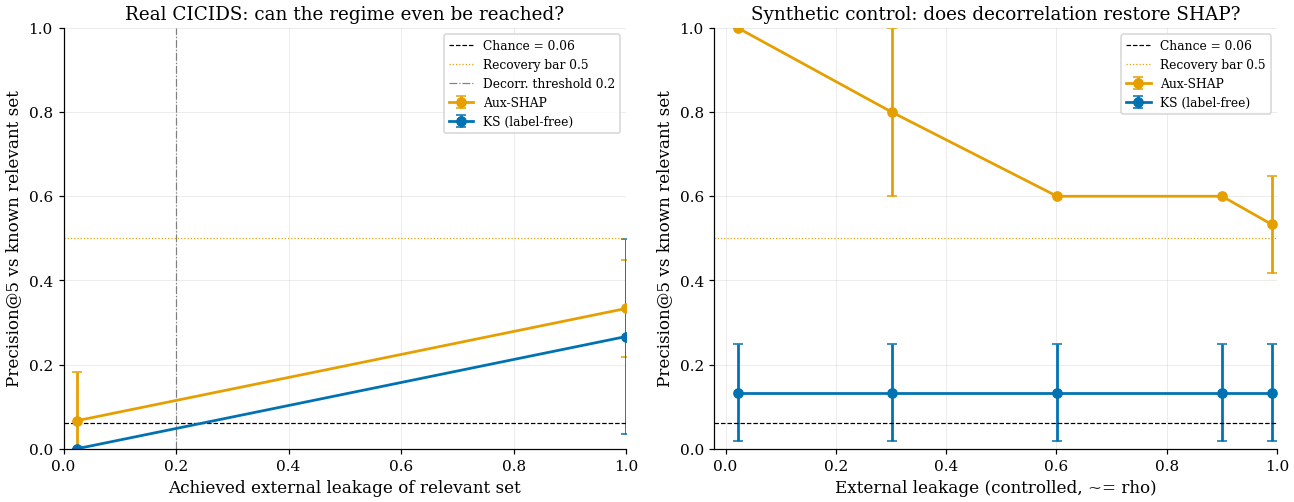

In [8]:
def agg(arm, level, method, col='precision'):
    s = res[(res['arm'] == arm) & (res['level'] == level) & (res['method'] == method)][col]
    return float(s.mean()), float(s.std())

def leak_of(arm, level):
    return float(res[(res['arm'] == arm) & (res['level'] == level)]['leakage'].mean())

# real table
real_tbl = pd.DataFrame({
    'set': ['lowest_redundancy', 'highest_redundancy'],
    'leakage': [round(leak_of('real', 'real_low'), 3), round(leak_of('real', 'real_high'), 3)],
    'aux_shap': [round(agg('real', 'real_low', 'aux_shap')[0], 3),
                 round(agg('real', 'real_high', 'aux_shap')[0], 3)],
    'ks': [round(agg('real', 'real_low', 'ks')[0], 3),
           round(agg('real', 'real_high', 'ks')[0], 3)],
})
print('REAL arm  -- precision@%d vs known relevant set:' % K_PRIMARY)
print(real_tbl.to_string(index=False))

# synthetic table
syn_tbl = pd.DataFrame({
    'rho': RHO_LEVELS,
    'leakage': [round(leak_of('syn', f'rho_{r}'), 3) for r in RHO_LEVELS],
    'aux_shap': [round(agg('syn', f'rho_{r}', 'aux_shap')[0], 3) for r in RHO_LEVELS],
    'ks': [round(agg('syn', f'rho_{r}', 'ks')[0], 3) for r in RHO_LEVELS],
})
print('\nSYNTHETIC arm  -- precision@%d vs known relevant set:' % K_PRIMARY)
print(syn_tbl.to_string(index=False))
print(f'\nChance ~ {CHANCE:.3f}.')
real_tbl.to_csv(TABLES / '07g_real_arm.csv', index=False)
syn_tbl.to_csv(TABLES / '07g_synthetic_curve.csv', index=False)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.8))

# Panel A: real arm
xr = [leak_of('real', 'real_low'), leak_of('real', 'real_high')]
for m in ['aux_shap', 'ks']:
    ms = [agg('real', 'real_low', m)[0], agg('real', 'real_high', m)[0]]
    es = [agg('real', 'real_low', m)[1], agg('real', 'real_high', m)[1]]
    axA.errorbar(xr, ms, yerr=es, marker='o', capsize=3, color=METHOD_COLOR[m],
                 label=('Aux-SHAP' if m == 'aux_shap' else 'KS (label-free)'))
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
axA.axhline(RECOVER_MIN, ls=':', color='#E69F00', lw=0.8, label=f'Recovery bar {RECOVER_MIN}')
axA.axvline(REAL_DECORR_MAX, ls='-.', color='grey', lw=0.8, label=f'Decorr. threshold {REAL_DECORR_MAX}')
axA.set_xlabel('Achieved external leakage of relevant set')
axA.set_ylabel(f'Precision@{K_PRIMARY} vs known relevant set')
axA.set_ylim(0, 1.0); axA.set_xlim(0, 1.0)
axA.set_title('Real CICIDS: can the regime even be reached?')
axA.legend(fontsize=8)

# Panel B: synthetic curve
xs = [leak_of('syn', f'rho_{r}') for r in RHO_LEVELS]
for m in ['aux_shap', 'ks']:
    ms = [agg('syn', f'rho_{r}', m)[0] for r in RHO_LEVELS]
    es = [agg('syn', f'rho_{r}', m)[1] for r in RHO_LEVELS]
    axB.errorbar(xs, ms, yerr=es, marker='o', capsize=3, color=METHOD_COLOR[m],
                 label=('Aux-SHAP' if m == 'aux_shap' else 'KS (label-free)'))
axB.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
axB.axhline(SYN_LOW_MIN, ls=':', color='#E69F00', lw=0.8, label=f'Recovery bar {SYN_LOW_MIN}')
axB.set_xlabel('External leakage (controlled, ~= rho)')
axB.set_ylabel(f'Precision@{K_PRIMARY} vs known relevant set')
axB.set_ylim(0, 1.0); axB.set_xlim(-0.02, 1.0)
axB.set_title('Synthetic control: does decorrelation restore SHAP?')
axB.legend(fontsize=8)

fig.tight_layout(); save_figure(fig, '07g_decorrelated_limit'); plt.show()

## 8. Pre-registered verdict (D023 / H2b)

The synthetic arm decides the mechanism; the real arm decides reachability. The combined
verdict maps onto the three pre-registered outcomes.

In [9]:
rho_sorted = sorted(RHO_LEVELS)
syn_low = agg('syn', f'rho_{rho_sorted[0]}', 'aux_shap')[0]
syn_high = agg('syn', f'rho_{rho_sorted[-1]}', 'aux_shap')[0]
syn_trend = syn_low - syn_high
mechanism_confirmed = (syn_low >= SYN_LOW_MIN) and (syn_trend >= SYN_TREND_MIN)
mechanism_refuted = syn_low < SYN_LOW_MIN

real_leak_low = leak_of('real', 'real_low')
real_shap_low = agg('real', 'real_low', 'aux_shap')[0]
real_reached = real_leak_low <= REAL_DECORR_MAX
real_recovers = real_shap_low >= RECOVER_MIN

if mechanism_refuted:
    verdict = 'IDENTIFIABILITY-REFUTED'
elif mechanism_confirmed and not real_reached:
    verdict = 'IDENTIFIABILITY-CONFIRMED / IDS-STRUCTURALLY-BLOCKED'
elif mechanism_confirmed and real_reached and real_recovers:
    verdict = 'IDENTIFIABILITY-CONFIRMED / REAL-POSITIVE-POLE'
elif mechanism_confirmed and real_reached and not real_recovers:
    verdict = 'MECHANISM-HOLDS-SYNTH-ONLY'
else:
    verdict = 'INCONCLUSIVE'

print('=' * 70)
print('DECORRELATED-LIMIT VERDICT (D023 / H2b)  -- precision@%d vs known set' % K_PRIMARY)
print('=' * 70)
print(f'  SYNTHETIC  rho=0 (leak {leak_of("syn", f"rho_{rho_sorted[0]}"):.2f}): '
      f'aux_SHAP={syn_low:.3f}   rho={rho_sorted[-1]} (leak '
      f'{leak_of("syn", f"rho_{rho_sorted[-1]}"):.2f}): aux_SHAP={syn_high:.3f}   '
      f'trend={syn_trend:+.3f}')
print(f'  REAL low-redundancy (leak {real_leak_low:.3f}): aux_SHAP={real_shap_low:.3f}  '
      f'| REACHED decorrelated (<= {REAL_DECORR_MAX}): {real_reached}')
print(f'  chance = {CHANCE:.3f}')
print('-' * 70)
print(f'  mechanism confirmed (syn rho=0 >= {SYN_LOW_MIN} & trend >= {SYN_TREND_MIN}): '
      f'{mechanism_confirmed}')
print(f'  mechanism refuted  (syn rho=0 < {SYN_LOW_MIN}): {mechanism_refuted}')
print(f'  real reached regime & recovered: {real_reached and real_recovers}')
print(f'\n--> VERDICT: {verdict}')
MSG = {
    'IDENTIFIABILITY-REFUTED':
        'SHAP fails even with a perfectly identifiable target (rho=0). Correlation is not '
        'the mechanism; explanation localization is unreliable regardless. Unconditional '
        'negative hardens.',
    'IDENTIFIABILITY-CONFIRMED / IDS-STRUCTURALLY-BLOCKED':
        'Decorrelation restores SHAP (synthetic), but real CICIDS cannot reach low '
        'leakage. Complete causal story: localization fails on IDS data because of '
        'structural feature redundancy -- measurable, with a deployment diagnostic.',
    'IDENTIFIABILITY-CONFIRMED / REAL-POSITIVE-POLE':
        'Decorrelation restores SHAP AND real CICIDS reaches a low-leakage set where SHAP '
        'recovers. A real-data positive pole survives.',
    'MECHANISM-HOLDS-SYNTH-ONLY':
        'Synthetic mechanism holds but real low-redundancy features still fail -- a second '
        'factor beyond correlation is at work on real data; investigate.',
    'INCONCLUSIVE':
        'Synthetic recovery present but no clean trend; report and let breadth decide.',
}[verdict]
print('   ' + MSG)

DECORRELATED-LIMIT VERDICT (D023 / H2b)  -- precision@5 vs known set
  SYNTHETIC  rho=0 (leak 0.02): aux_SHAP=1.000   rho=0.99 (leak 0.99): aux_SHAP=0.533   trend=+0.467
  REAL low-redundancy (leak 0.024): aux_SHAP=0.067  | REACHED decorrelated (<= 0.2): True
  chance = 0.061
----------------------------------------------------------------------
  mechanism confirmed (syn rho=0 >= 0.5 & trend >= 0.2): True
  mechanism refuted  (syn rho=0 < 0.5): False
  real reached regime & recovered: False

--> VERDICT: MECHANISM-HOLDS-SYNTH-ONLY
   Synthetic mechanism holds but real low-redundancy features still fail -- a second factor beyond correlation is at work on real data; investigate.


In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'rel_size': REL_SIZE, 'k_primary': K_PRIMARY, 'chance': CHANCE,
    'redundancy': {'min': float(REDUNDANCY.min()), 'median': float(np.median(REDUNDANCY)),
                   'max': float(REDUNDANCY.max()),
                   'counts_below': {str(t): int(np.sum(REDUNDANCY < t)) for t in RED_THRESHOLDS}},
    'real': {'leak_low': real_leak_low, 'shap_low': real_shap_low,
             'leak_high': leak_of('real', 'real_high'),
             'shap_high': agg('real', 'real_high', 'aux_shap')[0], 'reached': bool(real_reached)},
    'synthetic': [{'rho': r, 'leakage': leak_of('syn', f'rho_{r}'),
                   'aux_shap': agg('syn', f'rho_{r}', 'aux_shap')[0],
                   'ks': agg('syn', f'rho_{r}', 'ks')[0]} for r in RHO_LEVELS],
    'syn_low': syn_low, 'syn_high': syn_high, 'syn_trend': syn_trend,
    'mechanism_confirmed': bool(mechanism_confirmed), 'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F011',
    title='Decorrelated-limit + synthetic mechanism control for explanation localization',
    context='03_phase1_cicids/07g_decorrelated_limit',
    what_we_did=(
        'Closed 07f\'s construction gap (its lowest leakage was 0.37, never decorrelated). '
        'Quantified the feature-redundancy distribution; ran a real-data arm selecting the '
        'lowest-redundancy features to minimise external leakage; and a synthetic control '
        'arm sweeping a clean external-correlation knob rho from 0 upward to isolate the '
        'identifiability mechanism. Pre-registered H2b + gate (D023).'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Synthetic: aux-SHAP precision@%d at rho=0 = %.3f, '
        'at rho=%.2f = %.3f (trend %+.3f), chance %.3f. Real lowest-redundancy set: '
        'leakage %.3f (reached decorrelated: %s), aux-SHAP %.3f. Redundancy: median %.2f, '
        '%d of %d features below %.2f.'
        % (K_PRIMARY, syn_low, rho_sorted[-1], syn_high, syn_trend, CHANCE,
           real_leak_low, str(bool(real_reached)), real_shap_low,
           float(np.median(REDUNDANCY)), int(np.sum(REDUNDANCY < REAL_DECORR_MAX)),
           N_FEATURES, REAL_DECORR_MAX)
    ),
    why_it_matters=(
        '07f could not distinguish "correlation does not matter" from "could not escape '
        'correlation". The synthetic arm reaches leakage 0 and answers the mechanism '
        'directly; the real arm answers reachability. Together they settle whether the '
        'localization failure is non-identifiability under feature redundancy (a precise, '
        'measurable structural cause with a deployment diagnostic) or an unconditional '
        'unreliability of explanation localization.'
    ),
)
print('F011 logged. Record the call in a hand journal entry.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07g_decorrelated_limit.json
[FINDING LOGGED] F011: Decorrelated-limit + synthetic mechanism control for explanation localization
F011 logged. Record the call in a hand journal entry.


## 9. What this settles

- **IDENTIFIABILITY-CONFIRMED / IDS-STRUCTURALLY-BLOCKED** — the strongest honest outcome:
  SHAP recovers the relevant set the instant proxies are removed (synthetic), but real
  CICIDS cannot construct such a set (too few low-redundancy features). The Phase-1
  localization failures are explained by a single measurable cause — structural feature
  redundancy — and the thesis ships a pre-deployment diagnostic (the redundancy
  distribution) rather than a bare negative. Rewrite the regime map with *identifiability
  under feature redundancy* as the governing variable.
- **IDENTIFIABILITY-CONFIRMED / REAL-POSITIVE-POLE** — even stronger: a real low-leakage
  regime exists where SHAP localizes, so the positive pole survives on real data with the
  same diagnostic.
- **MECHANISM-HOLDS-SYNTH-ONLY** — the mechanism is real but a second factor breaks real
  low-redundancy features; report and investigate before any positive claim.
- **IDENTIFIABILITY-REFUTED** — SHAP fails even at rho=0 with a clean target. Correlation
  was not the story; explanation localization is unconditionally unreliable here, and the
  thesis rests cleanly on the redundancy benchmark plus the evaluation framework, with no
  surviving positive pole.

Whichever holds, this is the genuine end of the positive-shaped search: after it, correct
the 07f/F010 record (the H2-REFUTED-FLAT verdict was construction-limited), update the
regime map, and move to breadth (UNSW + XGBoost) — where measuring each dataset's feature
redundancy becomes a first-class part of the protocol, and a less-collinear dataset could
let the real arm reach the decorrelated regime that CICIDS forbids.

Record the call by hand:

In [11]:
# add_journal_entry(
#     title='Notebook 07g decorrelated-limit verdict',
#     body='...the redundancy distribution, the synthetic rho=0 recovery + trend, the real '
#          'reachability, the verdict bucket, and the correction it forces on 07f/F010.',
# )